In this project, the Telco Customer Churn dataset is analyzed to explore patterns and relationships between customer characteristics and churn behavior. Exploratory Data Analysis (EDA) is performed to understand data distributions and feature relationships. The dataset is then preprocessed to prepare it for machine learning modeling. Multiple machine learning models are trained to predict customer churn, and model performance is evaluated and compared to determine the best performing approach.

# Telco Customer Churn Prediction

## Objective

The objective of this project is to build a machine learning model that predicts whether a telecom customer is likely to churn based on provided features.

By identifying high-risk customers in advance, the model aims to help the business improve customer retention strategies and reduce revenue loss.

### Phase 1. Understanding The Data (EDA)

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
df = pd.read_csv('Telco Customer Churn Rate.csv')

In [79]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [80]:
df.shape

(7043, 21)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [82]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#### Gender vs Churn

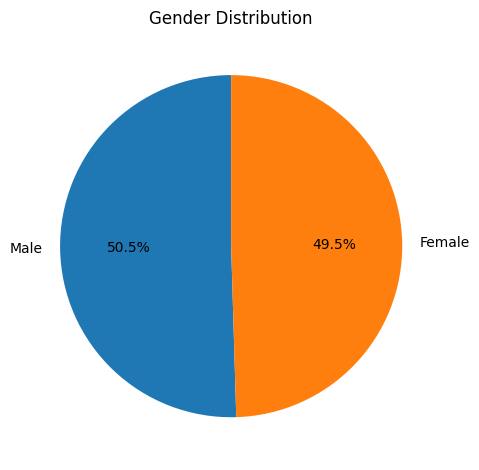

In [83]:
df["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("") 
plt.title("Gender Distribution")
plt.tight_layout()
plt.show()


In [84]:
gender_churn = df.groupby("gender")["Churn"].value_counts(normalize=True).unstack() * 100
gender_churn= gender_churn.round(2).astype(str) + "%"
gender_churn

Churn,No,Yes
gender,,
Female,73.08%,26.92%
Male,73.84%,26.16%


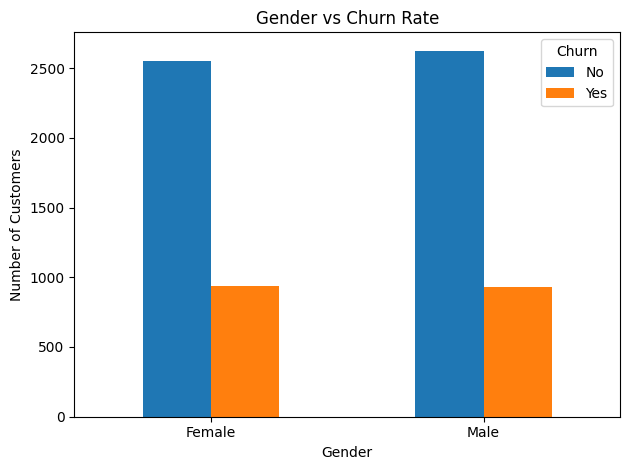

In [85]:
df.groupby(["gender","Churn"]).size().unstack().plot(kind="bar")

plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.title("Gender vs Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


The churn distribution across genders is very similar, indicating that gender is not a strong influencing factor in customer churn prediction.

#### Senior Citizen vs Churn

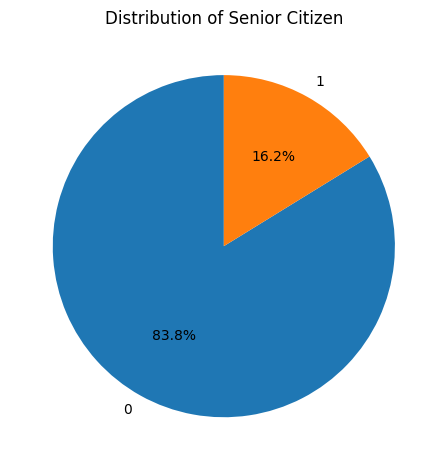

In [86]:
df["SeniorCitizen"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("") 
plt.title("Distribution of Senior Citizen")
plt.tight_layout()
plt.show()


In [87]:
df.groupby("SeniorCitizen")["Churn"].value_counts(normalize=True).unstack().style.format("{:.2%}")

Churn,No,Yes
SeniorCitizen,,
0,76.39%,23.61%
1,58.32%,41.68%


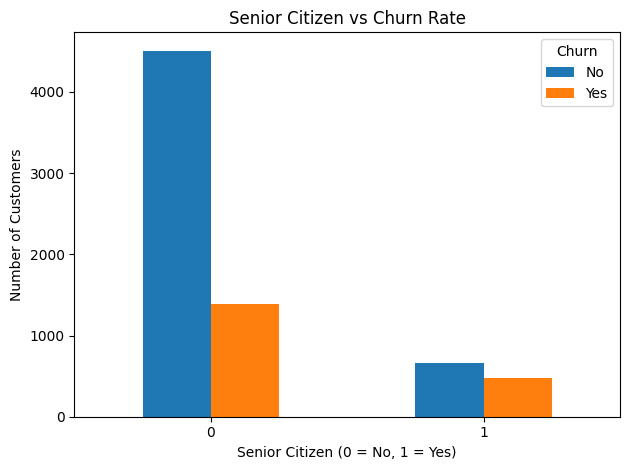

In [88]:
df.groupby(["SeniorCitizen","Churn"]).size().unstack().plot(kind="bar")

plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.title("Senior Citizen vs Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


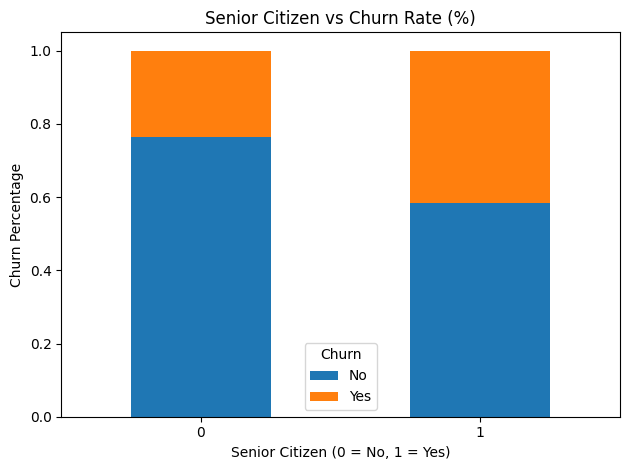

In [89]:
df.groupby("SeniorCitizen")["Churn"].value_counts(normalize=True).unstack().plot(kind="bar", stacked=True)

plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Percentage")
plt.title("Senior Citizen vs Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()


Senior citizens exhibit significantly higher churn rates (41.68%) compared to non-senior customers (23.61%), suggesting age group may influence customer retention behavior.

#### Partner vs Churn

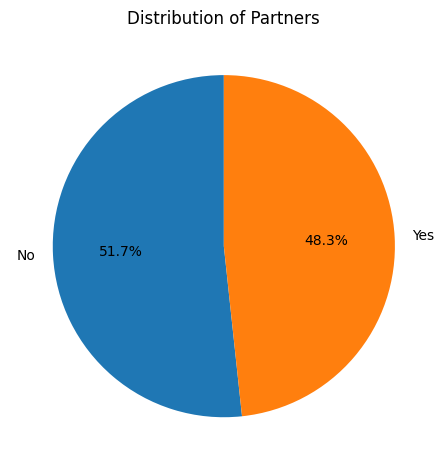

In [90]:
df["Partner"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("") 
plt.title("Distribution of Partners")
plt.tight_layout()
plt.show()


In [91]:
df.groupby("Partner")["Churn"].value_counts(normalize=True).unstack().style.format("{:.2%}")

Churn,No,Yes
Partner,,
No,67.04%,32.96%
Yes,80.34%,19.66%


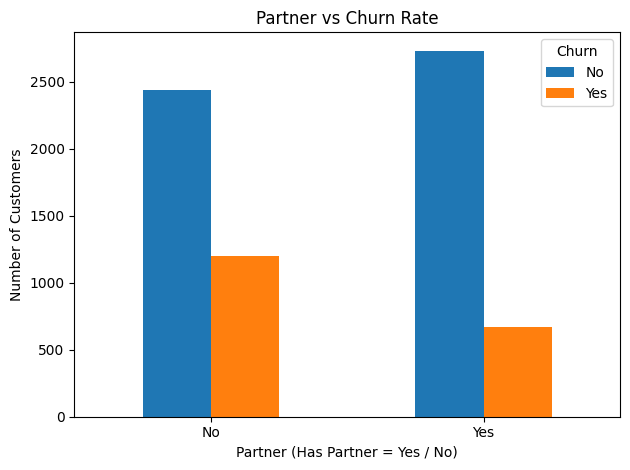

In [92]:
df.groupby(["Partner","Churn"]).size().unstack().plot(kind="bar")

plt.xlabel("Partner (Has Partner = Yes / No)")
plt.ylabel("Number of Customers")
plt.title("Partner vs Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Customers without partners show a slightly higher churn rate compared to customers with partners. This suggests that customers with partners may have better retention behavior.

#### Dependants vs Churn

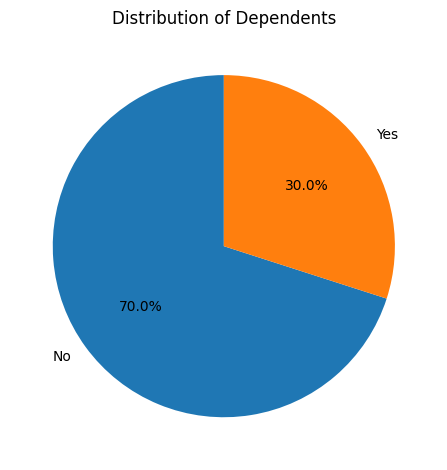

In [93]:
df["Dependents"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("") 
plt.title("Distribution of Dependents")
plt.tight_layout()
plt.show()


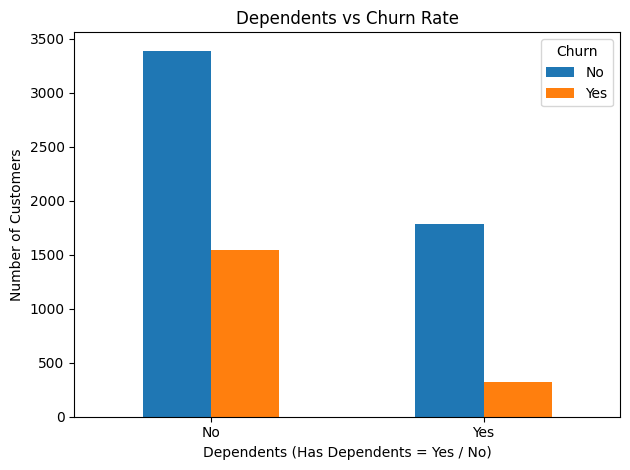

In [94]:
df.groupby(["Dependents","Churn"]).size().unstack().plot(kind="bar")

plt.xlabel("Dependents (Has Dependents = Yes / No)")
plt.ylabel("Number of Customers")
plt.title("Dependents vs Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [95]:
df.groupby("Dependents")["Churn"].value_counts(normalize=True).unstack().style.format("{:.2%}")

Churn,No,Yes
Dependents,,
No,68.72%,31.28%
Yes,84.55%,15.45%


Customers without dependents show a higher churn rate (31.28%) compared to customers with dependents (15.45%). This suggests that customers with family responsibilities tend to stay longer with the service.

#### Tenure vs Churn

In [96]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


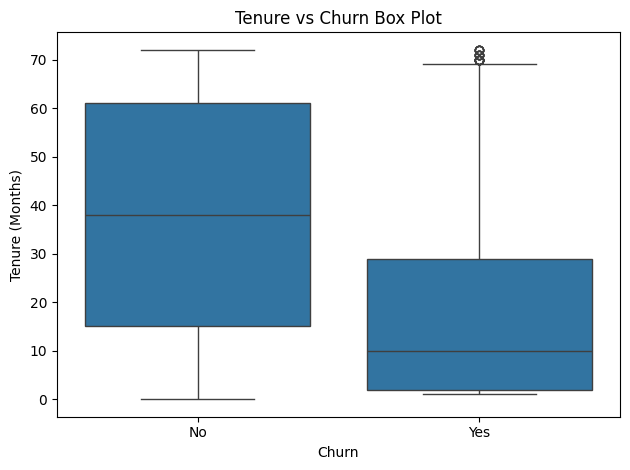

In [97]:
sns.boxplot(x="Churn", y="tenure", data=df)

plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.title("Tenure vs Churn Box Plot")
plt.tight_layout()
plt.show()

Customers who churn tend to have significantly lower tenure, with half of the churned customers leaving within the first 10 months, indicating that early customer experience plays a critical role in retention.

#### Phone Service vs Churn

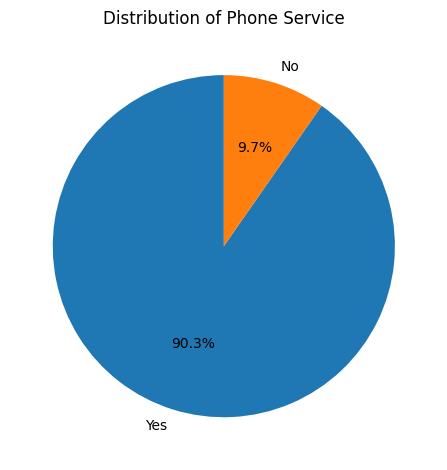

In [98]:
df["PhoneService"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("") 
plt.title("Distribution of Phone Service")
plt.tight_layout()
plt.show()


In [99]:
df.groupby('PhoneService')['Churn'].value_counts(normalize=True).unstack().style.format("{:.2%}")

Churn,No,Yes
PhoneService,,
No,75.07%,24.93%
Yes,73.29%,26.71%


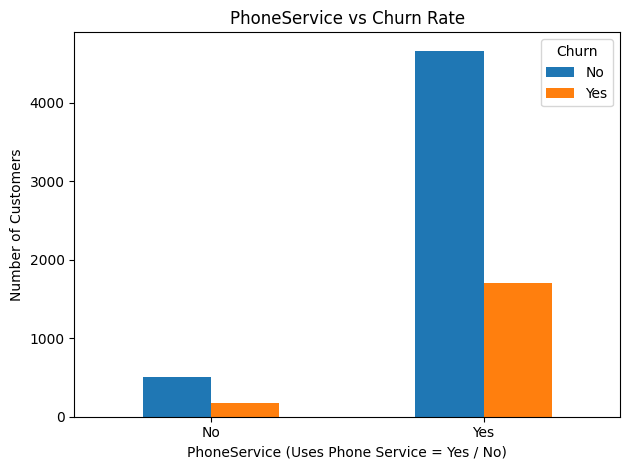

In [100]:
df.groupby(["PhoneService","Churn"]).size().unstack().plot(kind="bar")

plt.xlabel("PhoneService (Uses Phone Service = Yes / No)")
plt.ylabel("Number of Customers")
plt.title("PhoneService vs Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Phone service subscription does not significantly impact churn behavior.

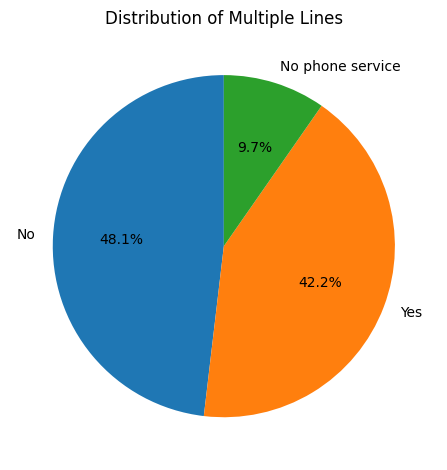

In [101]:
df["MultipleLines"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("") 
plt.title("Distribution of Multiple Lines")
plt.tight_layout()
plt.show()


In [102]:
df.groupby("MultipleLines")["Churn"].value_counts(normalize=True).unstack().style.format("{:.2%}")

Churn,No,Yes
MultipleLines,,
No,74.96%,25.04%
No phone service,75.07%,24.93%
Yes,71.39%,28.61%


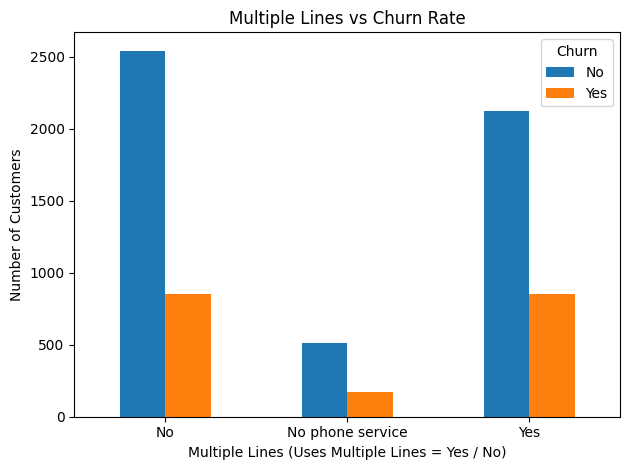

In [103]:
df.groupby(["MultipleLines","Churn"]).size().unstack().plot(kind="bar")

plt.xlabel("Multiple Lines (Uses Multiple Lines = Yes / No)")
plt.ylabel("Number of Customers")
plt.title("Multiple Lines vs Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Customers with multiple phone lines show a slightly higher churn rate (28.61%) compared to customers without multiple lines (~25%), although the difference is relatively small, suggesting that this feature may have limited predictive power.

#### Internet Service vs Churn

In [104]:
df['InternetService'].value_counts(normalize=True)*100

InternetService
Fiber optic    43.958540
DSL            34.374556
No             21.666903
Name: proportion, dtype: float64

In [105]:
df.groupby("InternetService")["Churn"].value_counts(normalize=True).unstack().style.format("{:.2%}")

Churn,No,Yes
InternetService,,
DSL,81.04%,18.96%
Fiber optic,58.11%,41.89%
No,92.60%,7.40%


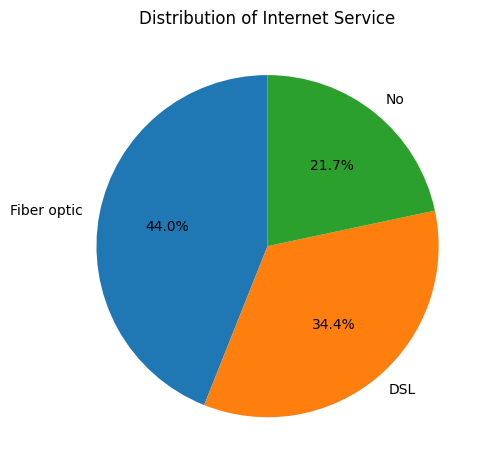

In [106]:
df["InternetService"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("") 
plt.title("Distribution of Internet Service")
plt.tight_layout()
plt.show()


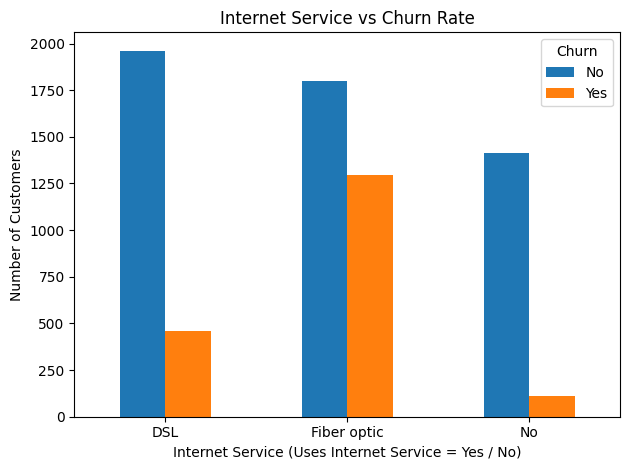

In [107]:
df.groupby(["InternetService","Churn"]).size().unstack().plot(kind="bar")

plt.xlabel("Internet Service (Uses Internet Service = Yes / No)")
plt.ylabel("Number of Customers")
plt.title("Internet Service vs Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Customers using fiber optic internet exhibit significantly higher churn rates (41.89%) compared to DSL users (18.96%) and customers without internet service (7.40%), indicating that internet service type is a strong predictor of churn.

### Onine Security vs Churn

In [108]:
df['OnlineSecurity'].value_counts(normalize=True)*100

OnlineSecurity
No                     49.666335
Yes                    28.666761
No internet service    21.666903
Name: proportion, dtype: float64

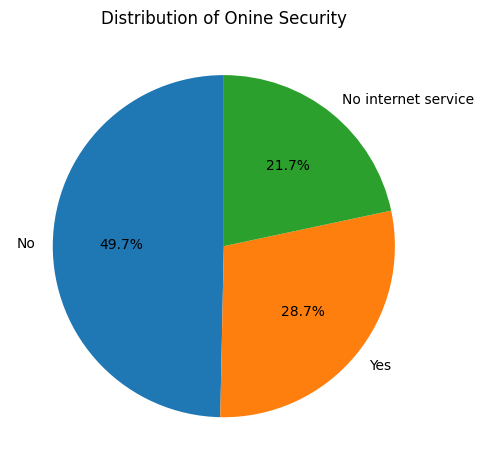

In [109]:
df['OnlineSecurity'].value_counts(normalize=True).plot(
    kind = 'pie',
    autopct = '%1.1f%%',
    startangle=90
)
plt.ylabel("") 
plt.title("Distribution of Onine Security")
plt.tight_layout()
plt.show()


In [110]:
df.groupby("OnlineSecurity")["Churn"].value_counts(normalize=True).unstack().style.format("{:.2%}")

Churn,No,Yes
OnlineSecurity,,
No,58.23%,41.77%
No internet service,92.60%,7.40%
Yes,85.39%,14.61%


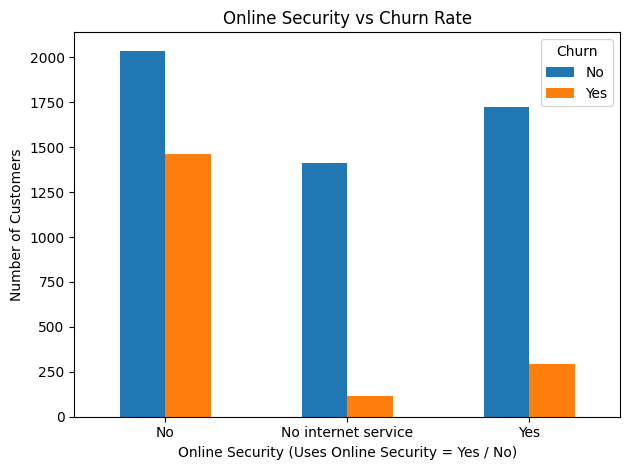

In [111]:
df.groupby(["OnlineSecurity","Churn"]).size().unstack().plot(kind="bar")

plt.xlabel("Online Security (Uses Online Security = Yes / No)")
plt.ylabel("Number of Customers")
plt.title("Online Security vs Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Customers without online security show significantly higher churn rates (41.77%) compared to customers who subscribe to online security (14.61%), indicating that value-added services play an important role in customer retention.

#### Online Backup vs Churn Rate

In [112]:
df['OnlineBackup'].value_counts(normalize=True)*100

OnlineBackup
No                     43.844952
Yes                    34.488144
No internet service    21.666903
Name: proportion, dtype: float64

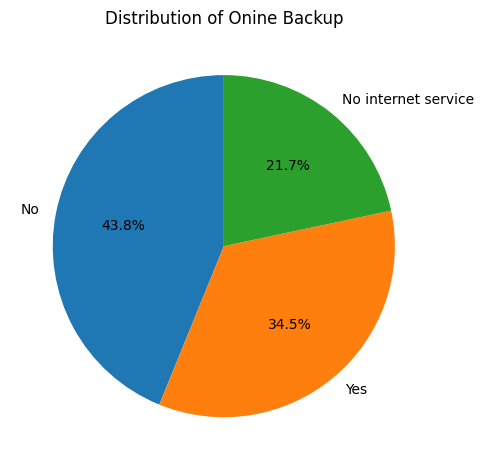

In [113]:
df['OnlineBackup'].value_counts(normalize=True).plot(
    kind = 'pie',
    autopct = '%1.1f%%',
    startangle=90
)
plt.ylabel("") 
plt.title("Distribution of Onine Backup")
plt.tight_layout()
plt.show()


In [114]:
df.groupby("OnlineBackup")["Churn"].value_counts(normalize=True).unstack().style.format("{:.2%}")

Churn,No,Yes
OnlineBackup,,
No,60.07%,39.93%
No internet service,92.60%,7.40%
Yes,78.47%,21.53%


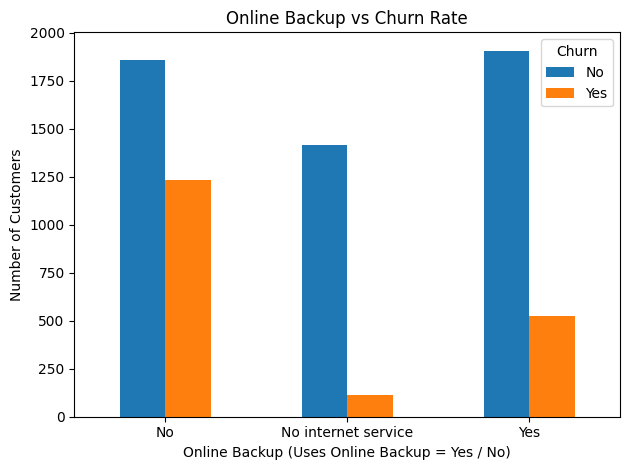

In [115]:
df.groupby(["OnlineBackup","Churn"]).size().unstack().plot(kind="bar")

plt.xlabel("Online Backup (Uses Online Backup = Yes / No)")
plt.ylabel("Number of Customers")
plt.title("Online Backup vs Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Customers without online backup have higher churn compared to those who subscribe to online backup.

#### Device Protection vs Churn

In [116]:
df['DeviceProtection'].value_counts(normalize=True)*100

DeviceProtection
No                     43.944342
Yes                    34.388755
No internet service    21.666903
Name: proportion, dtype: float64

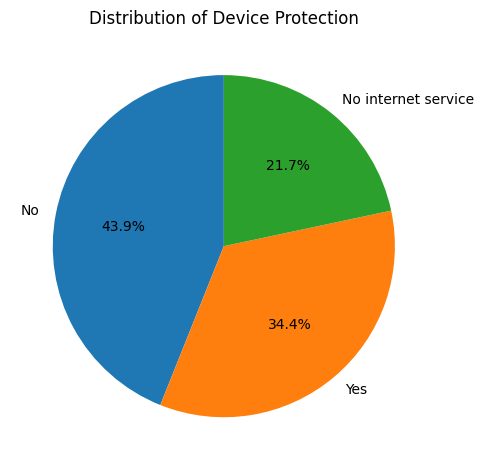

In [117]:
df['DeviceProtection'].value_counts(normalize=True).plot(
    kind = 'pie',
    autopct = '%1.1f%%',
    startangle=90
)
plt.ylabel("") 
plt.title("Distribution of Device Protection")
plt.tight_layout()
plt.show()


In [118]:
df.groupby("DeviceProtection")["Churn"].value_counts(normalize=True).unstack().style.format("{:.2%}")

Churn,No,Yes
DeviceProtection,,
No,60.87%,39.13%
No internet service,92.60%,7.40%
Yes,77.50%,22.50%


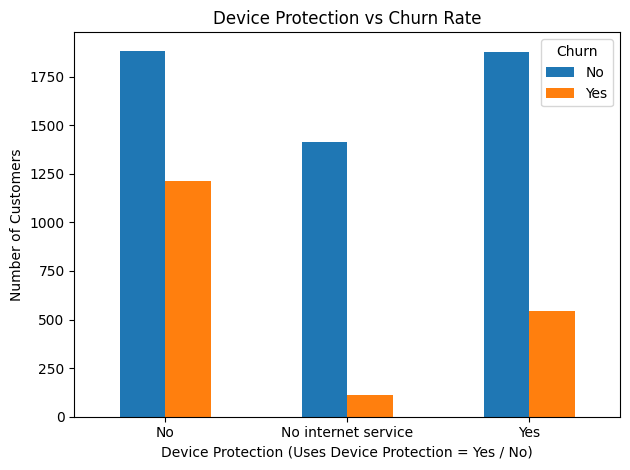

In [119]:
df.groupby(["DeviceProtection","Churn"]).size().unstack().plot(kind="bar")

plt.xlabel("Device Protection (Uses Device Protection = Yes / No)")
plt.ylabel("Number of Customers")
plt.title("Device Protection vs Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Customers who do not subscribe to device protection exhibit significantly higher churn rates (39.13%) compared to customers who use the service (22.50%), suggesting that bundled service adoption improves customer retention.

#### Tech Support vs Churn

In [120]:
df['TechSupport'].value_counts(normalize=True)*100

TechSupport
No                     49.311373
Yes                    29.021724
No internet service    21.666903
Name: proportion, dtype: float64

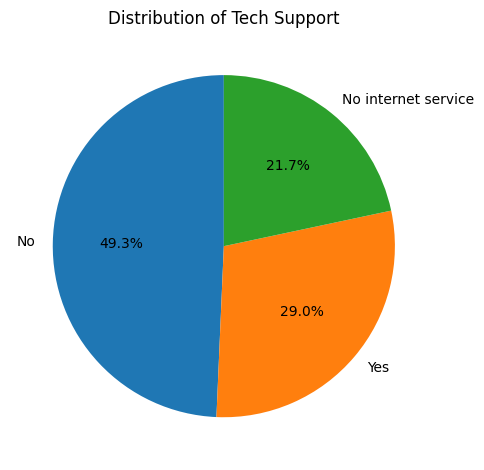

In [121]:
df['TechSupport'].value_counts(normalize=True).plot(
    kind = 'pie',
    autopct = '%1.1f%%',
    startangle=90
)
plt.ylabel("") 
plt.title("Distribution of Tech Support")
plt.tight_layout()
plt.show()


In [122]:
df.groupby("TechSupport")["Churn"].value_counts(normalize=True).unstack().style.format("{:.2%}")

Churn,No,Yes
TechSupport,,
No,58.36%,41.64%
No internet service,92.60%,7.40%
Yes,84.83%,15.17%


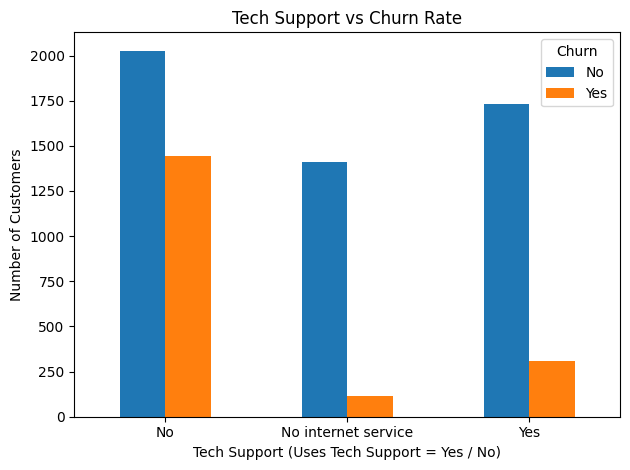

In [123]:
df.groupby(["TechSupport","Churn"]).size().unstack().plot(kind="bar")

plt.xlabel("Tech Support (Uses Tech Support = Yes / No)")
plt.ylabel("Number of Customers")
plt.title("Tech Support vs Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Customers without technical support services show significantly higher churn rates (41.64%) compared to customers with technical support (15.17%). This indicates that customer service quality and technical assistance play an important role in customer retention.

#### Streaming TV vs Churn

In [124]:
df['StreamingTV'].value_counts(normalize=True)*100

StreamingTV
No                     39.897771
Yes                    38.435326
No internet service    21.666903
Name: proportion, dtype: float64

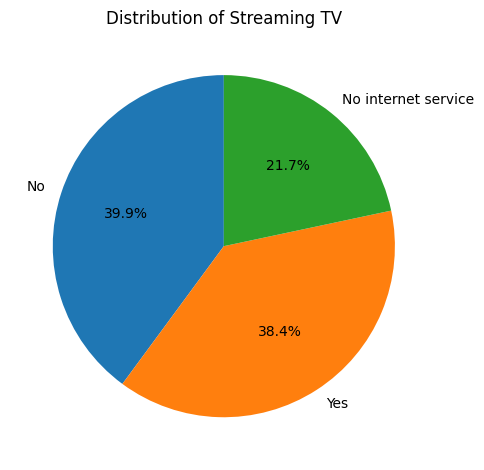

In [125]:
df['StreamingTV'].value_counts(normalize=True).plot(
    kind = 'pie',
    autopct = '%1.1f%%',
    startangle=90
)
plt.ylabel("") 
plt.title("Distribution of Streaming TV")
plt.tight_layout()
plt.show()


In [126]:
df.groupby("StreamingTV")["Churn"].value_counts(normalize=True).unstack().style.format("{:.2%}")

Churn,No,Yes
StreamingTV,,
No,66.48%,33.52%
No internet service,92.60%,7.40%
Yes,69.93%,30.07%


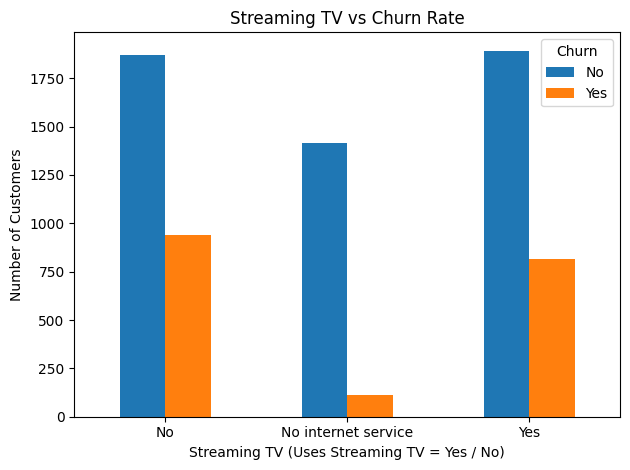

In [127]:
df.groupby(["StreamingTV","Churn"]).size().unstack().plot(kind="bar")

plt.xlabel("Streaming TV (Uses Streaming TV = Yes / No)")
plt.ylabel("Number of Customers")
plt.title("Streaming TV vs Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

StreamingTV service does not appear to significantly influence customer churn, as churn rates remain relatively similar between customers who use the service and those who do not.

#### Streaming Movies vs Churn

In [128]:
df['StreamingMovies'].value_counts(normalize=True)*100

StreamingMovies
No                     39.542808
Yes                    38.790288
No internet service    21.666903
Name: proportion, dtype: float64

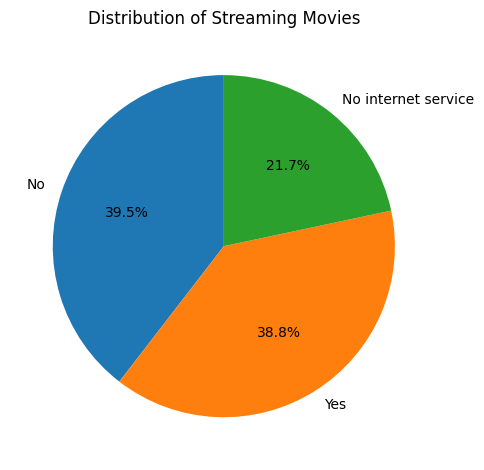

In [129]:
df['StreamingMovies'].value_counts(normalize=True).plot(
    kind = 'pie',
    autopct = '%1.1f%%',
    startangle=90
)
plt.ylabel("") 
plt.title("Distribution of Streaming Movies")
plt.tight_layout()
plt.show()


In [130]:
df.groupby("StreamingMovies")["Churn"].value_counts(normalize=True).unstack().style.format("{:.2%}")

Churn,No,Yes
StreamingMovies,,
No,66.32%,33.68%
No internet service,92.60%,7.40%
Yes,70.06%,29.94%


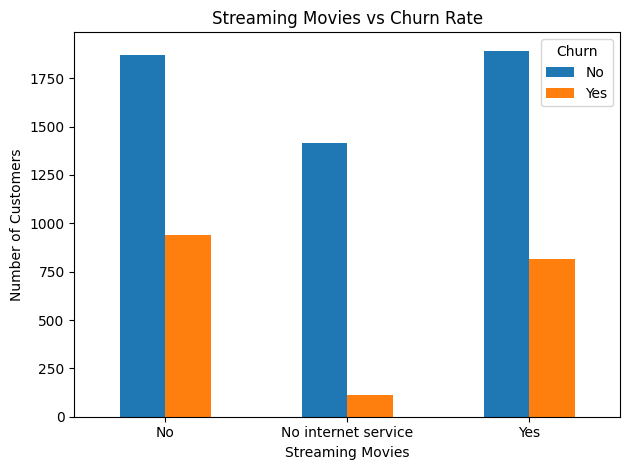

In [131]:
df.groupby(["StreamingTV","Churn"]).size().unstack().plot(kind="bar")

plt.xlabel("Streaming Movies")
plt.ylabel("Number of Customers")
plt.title("Streaming Movies vs Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

StreamingMovies is probably not a strong standalone churn predictor.

#### Contract vs Churn

In [132]:
df['Contract'].value_counts(normalize=True)*100

Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64

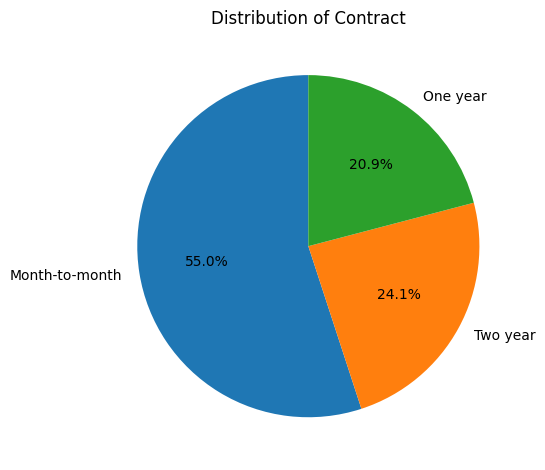

In [133]:
df['Contract'].value_counts(normalize=True).plot(
    kind = 'pie',
    autopct = '%1.1f%%',
    startangle=90
)
plt.ylabel("") 
plt.title("Distribution of Contract")
plt.tight_layout()
plt.show()


In [134]:
df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack().style.format("{:.2%}")

Churn,No,Yes
Contract,,
Month-to-month,57.29%,42.71%
One year,88.73%,11.27%
Two year,97.17%,2.83%


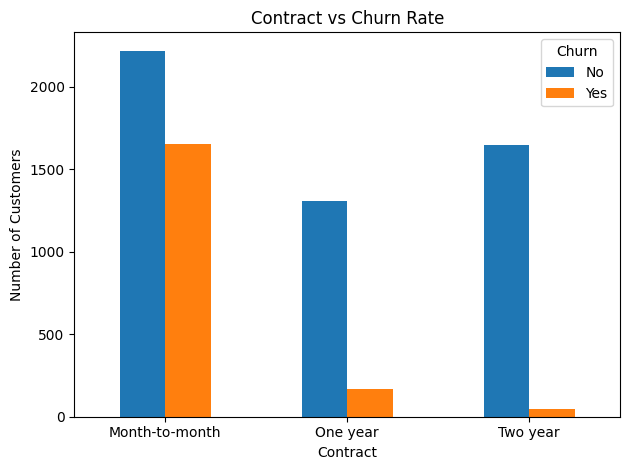

In [135]:
df.groupby(["Contract","Churn"]).size().unstack().plot(kind="bar")

plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.title("Contract vs Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Customers with month-to-month contracts show significantly higher churn rates (42.71%) compared to one-year (11.27%) and two-year contracts (2.83%). This indicates that contract duration is one of the strongest predictors of customer churn.

#### Paperless Billing

In [136]:
df['PaperlessBilling'].value_counts(normalize=True)*100

PaperlessBilling
Yes    59.221922
No     40.778078
Name: proportion, dtype: float64

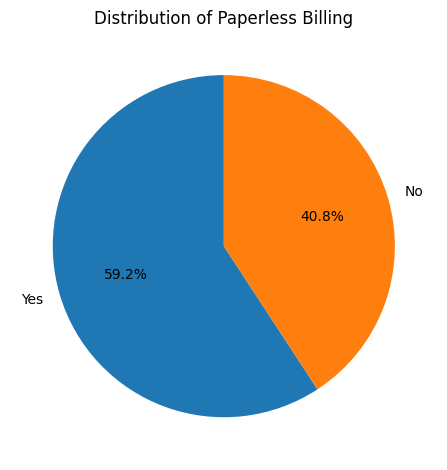

In [137]:
df['PaperlessBilling'].value_counts(normalize=True).plot(
    kind = 'pie',
    autopct = '%1.1f%%',
    startangle=90
)
plt.ylabel("") 
plt.title("Distribution of Paperless Billing")
plt.tight_layout()
plt.show()


In [138]:
df.groupby("PaperlessBilling")["Churn"].value_counts(normalize=True).unstack().style.format("{:.2%}")

Churn,No,Yes
PaperlessBilling,,
No,83.67%,16.33%
Yes,66.43%,33.57%


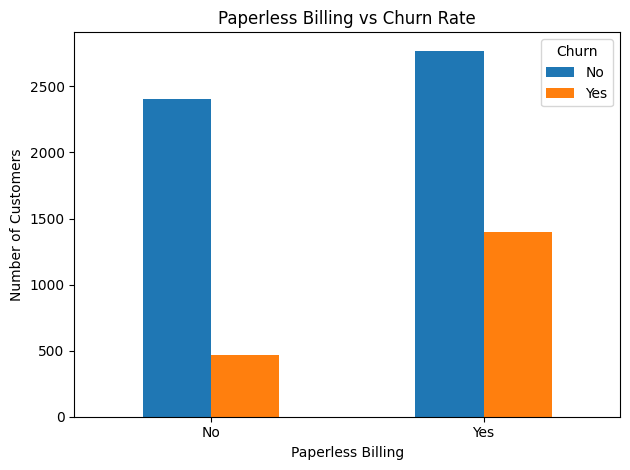

In [139]:
df.groupby(["PaperlessBilling","Churn"]).size().unstack().plot(kind="bar")

plt.xlabel("Paperless Billing")
plt.ylabel("Number of Customers")
plt.title("Paperless Billing vs Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Customers using paperless billing exhibit higher churn rates (33.57%) compared to customers who do not use paperless billing (16.33%), suggesting that billing preference may be associated with customer retention behavior.

#### Payment Method vs Churn

In [140]:
df['PaymentMethod'].value_counts(normalize=True)*100

PaymentMethod
Electronic check             33.579441
Mailed check                 22.887974
Bank transfer (automatic)    21.922476
Credit card (automatic)      21.610109
Name: proportion, dtype: float64

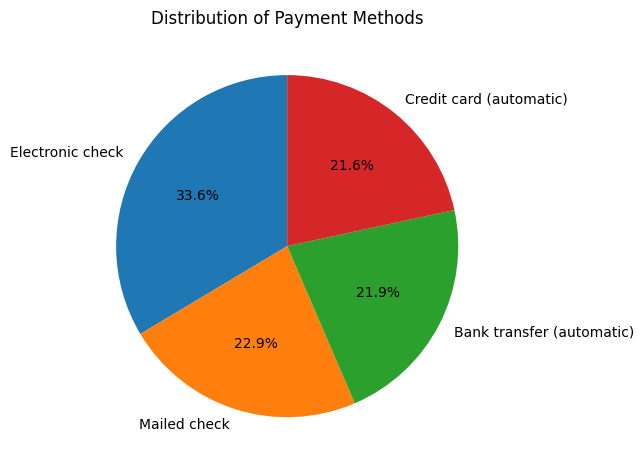

In [141]:
df['PaymentMethod'].value_counts(normalize=True).plot(
    kind = 'pie',
    autopct = '%1.1f%%',
    startangle=90
)
plt.ylabel("") 
plt.title("Distribution of Payment Methods")
plt.tight_layout()
plt.show()


In [142]:
df.groupby("PaymentMethod")["Churn"].value_counts(normalize=True).unstack().style.format("{:.2%}")

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29%,16.71%
Credit card (automatic),84.76%,15.24%
Electronic check,54.71%,45.29%
Mailed check,80.89%,19.11%


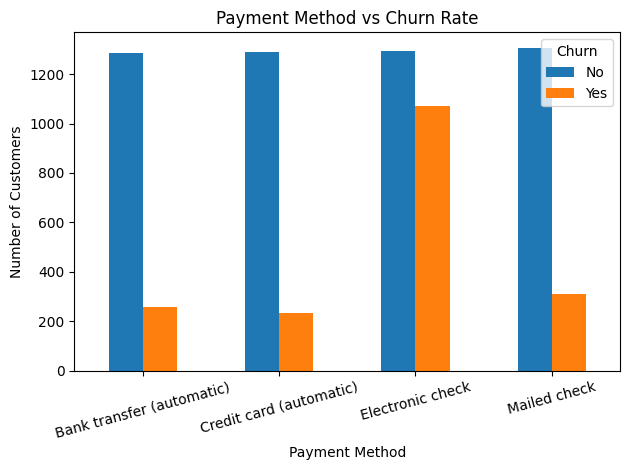

In [143]:
df.groupby(["PaymentMethod","Churn"]).size().unstack().plot(kind="bar")

plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.title("Payment Method vs Churn Rate")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Payment method appears to be a strong predictor of churn, with electronic check users showing the highest churn probability, suggesting that customers with automated payment methods tend to be more loyal.

#### Monthly Charges vs Churn

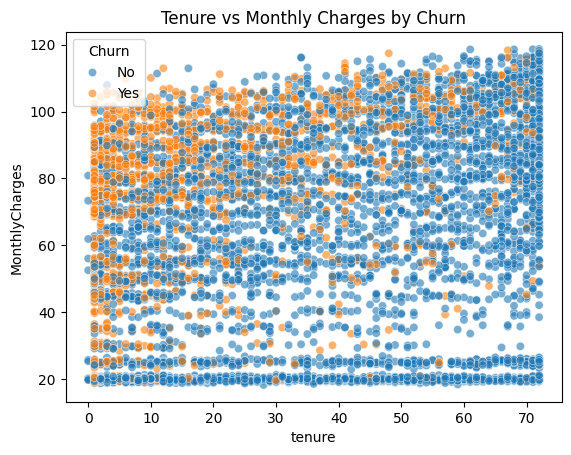

In [144]:
sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.6
)

plt.title("Tenure vs Monthly Charges by Churn")
plt.show()

Customers with higher monthly charges tend to have higher churn, especially when tenure is low. New customers paying higher charges are more likely to leave the service.

### Phase 2: Data Preprocessing

#### Train Test Split

In [145]:
from sklearn.model_selection import train_test_split

In [146]:
X = df.drop(columns=['customerID', 'Churn', 'TotalCharges'])
Y = df['Churn']

In [147]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

#### Encoding

In [148]:
categorical = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PaperlessBilling', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'PaymentMethod', 'Contract']

numerical = ['MonthlyCharges', 'tenure']

In [149]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

In [150]:
le = LabelEncoder()

Y_train = le.fit_transform(Y_train)
Y_test = le.transform(Y_test)

In [151]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ], remainder="passthrough"
)

In [152]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


### Phase 3: Model Implementation And Evaluation

In [153]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

#### 1. Logistic Regression

In [154]:
model = LogisticRegression(max_iter=1000)

In [155]:
model.fit(X_train_processed, Y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [156]:
y_pred_log = model.predict(X_test_processed)

In [157]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_test, y_pred_log)
print("Accuracy:", accuracy)


Accuracy: 0.8204400283889283


In [158]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred_log)
print(cm)


[[939  97]
 [156 217]]


#### 2. XG Boost

In [159]:
xgb = XGBClassifier()
xgb.fit(X_train_processed, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [160]:
y_pred_XG = xgb.predict(X_test_processed)

In [162]:
print("Accuracy:", accuracy_score(Y_test, y_pred_XG))
print(confusion_matrix(Y_test, y_pred_XG))

Accuracy: 0.7934705464868701
[[925 111]
 [180 193]]


#### 3. SVM

In [ ]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train_processed, Y_train)
y_pred_svm = svm.predict(X_test_processed)

In [164]:
print("Accuracy:", accuracy_score(Y_test, y_pred_svm))
print(confusion_matrix(Y_test, y_pred_svm))

Accuracy: 0.8133427963094393
[[952  84]
 [179 194]]


Among the tested models, Logistic Regression performed the best with an accuracy of 0.82, followed by SVM with 0.81, while XGBoost achieved 0.79. This suggests that for this dataset, a simpler linear model like Logistic Regression is sufficient to capture the patterns related to customer churn.